# 2 Descriptive (Spatial) Analytics

After completing data preparation in Section 1, the analytical perspective shifts from *"what is in the data"* to *"what does the data tell us"*. This section uses descriptive and exploratory methods to characterize taxi demand patterns in Chicago — without yet constructing any predictive model. The goal is to surface structure, identify spatial hot spots, and develop an empirical understanding of demand dynamics that will directly inform the predictive modeling in Section 3 and the operational recommendations in Section 5.

The main analytical questions guiding this section are:
1. How does demand vary across time (hour, weekday, month, season)?
2. How does demand vary across space, and where are the natural pickup hot spots?
3. How do temporal and spatial patterns interact?
4. Where do trips actually go — what are the dominant origin-destination flows?
5. Which external factors, primarily weather, modulate demand and how strongly?
6. How do individual trip characteristics (length, price, idle time, utilization rate) differ between regions?
7. How sensitive are the observed patterns to the chosen spatial and temporal resolution?

Each of these questions maps back to one of the consulting decisions outlined in Section 1: **strategic** (where to enter the market), **tactical** (when and how many vehicles to deploy), and **operational** (idle time, repositioning, charging). This section is therefore not a descriptive exercise for its own sake, but a structured exploration that delivers evidence for the final recommendations to the client.

Before the analyses begin, a short overview of the central trip variables (trip duration, trip distance, trip total, idle time, utilization rate) is provided. These baseline distributions serve as the reference against which all subsequent spatial and temporal variations are interpreted.

- *2.1 Temporal Patterns*
- *2.2 Spatial Patterns and Hotspot Identification*
- *2.3 Spatio-Temporal Interplay*
- *2.4 Origin-Destination Flows*
- *2.5 External Drivers: Weather*
- *2.6 Spatial Variation in Trip Characteristics*
- *2.7 Resolution Sensitivity*
- *2.8 Summary and Implications*

Sections 2.1 to 2.3 follow a deliberate sequence: first time alone, then space alone, then their joint interaction. This separation makes each marginal effect interpretable before the combined view is presented. Sections 2.4 to 2.6 broaden the perspective to additional dimensions — destination flows, weather effects, and intra-area trip differences — that are conceptually independent of the demand-count framing used so far. Section 2.7 systematically tests how the chosen spatial resolution affects the observed patterns, and Section 2.8 consolidates the findings into operational implications for the fleet operator.

## Structure Rationale

The chapter separates each analytical dimension before recombining them. The order is time → space → joint, then additional dimensions (OD, weather, trip characteristics), then a sensitivity check, then the synthesis.

### 2.1 Temporal Patterns
Demand is aggregated at city level over time. Required outputs:

- Line plot of `demand_count` by hour of day, split into weekday vs. weekend
- Heatmap weekday × hour at city level
- Monthly demand profile over the full sample period
- Time courses of `trip_miles`, `trip_seconds`, `trip_total`, `idle_time`, `utilization_rate`, ... aggregated by hour and weekday

Time is treated first because the temporal cycle is the strongest single driver of demand variation and is well-defined at city level. Once the rhythm is established, spatial effects in 2.2 and 2.3 can be read against it.

### 2.2 Spatial Patterns and Hotspot Identification
Demand is aggregated over all hours and shown spatially through two complementary methods.

Grid-based:
- Choropleth of `demand_count` on Community Areas
- Choropleth of `demand_count` on H3 r? cells (default spatial unit)

Grid-free:
- Gaussian Mixture Model fitted on raw pickup coordinates (latitude, longitude), with the number of components selected via BIC
- Kernel Density Estimation on the same coordinates, plotted as contour map over Chicago

GMM is mandatory per the task description. KDE is added because the cluster centres from GMM do not visualise density gradients well; the contour map fills that gap. The grid-vs-grid-free comparison is the substantive point: if natural pickup clusters do not align with Community Area boundaries, the administrative units are the wrong service-zone proxy.

### 2.3 Spatio-Temporal Interplay
`demand_count` is shown jointly over (spatial unit × time). Three artefacts:

- Heatmap matrix: rows = top-N H3 r? cells (or Community Areas), columns = hour of day, colour = mean `demand_count`
- Small multiples: four to six maps of Chicago at representative time slices (e.g. weekday 1am, 7am, 1pm, 7pm; vs. Saturday?), choropleth on the same spatial unit as 2.2
- Line plot: hourly demand profile for the top five hexagons over a typical day

The three artefacts exist because no single plot captures both dimensions well. The matrix is dense and exact but loses geography; the small multiples retain geography but lose continuity; the line plot makes the dynamics of individual hotspots readable.

### 2.4 Origin-Destination Flows
Pickup → dropoff pairs are aggregated at Community Area level (H3 r? produces too many low-volume pairs for a readable OD analysis). Required outputs:

- Top 20–50 OD pairs as a sorted table with trip count, mean trip distance and mean trip total
- Chord or Sankey diagram of the major flows (I don't even know what that is, but AI says it should be good)
- Asymmetry score per OD pair: `(forward − backward) / (forward + backward)`, used to flag corridors with structural repositioning need

Anchoring on pickups alone misses where vehicles end up after a trip, which is the relevant question for repositioning.

### 2.5 External Drivers: Weather
The hourly weather data from Section 1.5 is merged onto the hourly demand aggregate by `timestamp_h`. Required outputs:

- `demand_count` vs. `temp_h`, binned and plotted with median and IQR per bin
- Same for `precip_h` and `snow_h`
- Comparison of rainy vs. dry days at the same hour of day, to control for the time-of-day confound (rain peaks in the afternoon, demand also peaks in the afternoon — a raw correlation would mostly capture this)
- in generel problem of analyzing temp e.g., because this correlates with time => so try to cancel time-influence and look at data always at 4pm e.g. with different temps. 

Snowfall is analysed only for the winter months; outside winter the signal is too sparse. Weather has only a temporal component, so all comparisons here are city-level.

### 2.6 Spatial Variation in Trip Characteristics
For each Community Area and each H3 r? cell, the following per-area statistics are computed and visualised as choropleths (maybe I am listing too many variables, please recheck):

- mean `trip_miles`, mean `trip_seconds`
- mean `trip_total`, `price_per_mile`, `price_per_minute`
- mean `avg_speed_mph` (operational congestion indicator)
- median `idle_time` per taxi (skewed distribution, so median is used)
- mean `utilization_rate` (active driving time over time on shift)
- mean repositioning distance (Haversine from dropoff to next pickup of the same taxi, averaged within area)
- mean detour factor (`trip_miles` over straight-line pickup–dropoff distance)
- number of distinct companies operating in the area
- share of digital payments (`payment_type` ∈ {Credit Card, Mobile})
- mean tip rate (`tips` / `fare`, conditioned on `fare > 0`)

2.2 counts pickups; 2.6 describes what those pickups produce. Two areas can show the same `demand_count` and produce completely different trip economics, which drives fleet sizing, charging cadence and revenue per pickup.

### 2.7 Resolution Sensitivity
**Spatial sensitivity** (1h aggregate, H3 r4 / r6 / r8 + Community Areas):
- Table per resolution: number of cells, share of (cell × hour) with `demand_count > 0`, median and 99th-percentile demand, Gini coefficient
- Overlay histogram of `demand_count` distributions across resolutions
- Same hour of the same day on a map at three resolutions side by side

Census Tracts are excluded — Section 1.3 documented a 55% missing share, which would dominate any sensitivity effect.

**Temporal sensitivity** (H3 r?, 1h / 4h / 1d): short table on zero-rate and coefficient of variation, plus one example heatmap (cell × time) at the three bin widths. Treated briefly because temporal aggregation is a smoothing operation — variance drops with bin width, but the daily cycle shape does not change.

**GMM vs. grid**: one map with raw pickup points, GMM cluster centres from 2.2 and the top-10 cells at H3 r6 and r8 outlined; short note on the share of pickups captured by each. The point is that GMM is grid-independent, while grid-based hotspots are distorted by cell size — coarse grids merge separate clusters, fine grids split single ones.

Closes with a recommended spatial resolution for the predictive modelling in Section 3, chosen by the trade-off between spatial detail and zero-inflation of the target.

### 2.8 Summary and Implications
The findings from 2.1–2.7 are mapped onto the three consulting questions from Section 1.1:

- Strategic: which areas show consistently high demand across hours and weeks
- Tactical: how demand varies by hour, weekday and weather, with implications for vehicle counts
- Operational: where idle times and repositioning distances are highest, and where the trip mix favours short, high-throughput pickups versus long airport-style trips


## Setup and data loading

In [73]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
from matplotlib.collections import PolyCollection

PROCESSED = pathlib.Path("../processed")

def _load(name):
    return pd.read_parquet(PROCESSED / f"{name}.parquet")

# Small aggregates (all tiny)
agg_city_dow_hour  = _load("agg_city_dow_hour")    # (day_of_week, hour) -> n_trips, mean_trip_*
agg_city_month     = _load("agg_city_month")       # (month_start) -> n_trips
idle_city_dow_hour = _load("idle_city_dow_hour")   # (day_of_week, hour) -> mean_idle_secs, n
agg_h3r4_total     = _load("agg_h3r4_total")
agg_h3r5_total     = _load("agg_h3r5_total")       # (h3_r5) -> n_trips
agg_h3r6_total     = _load("agg_h3r6_total")       # (h3_r6) -> n_trips
agg_h3r7_total     = _load("agg_h3r7_total")       # (h3_r7) -> n_trips
agg_h3r8_total     = _load("agg_h3r8_total")
agg_ca_total       = _load("agg_ca_total")         # (pickup_community_area) -> n_trips
agg_h3r6_dow_hour  = _load("agg_h3r6_dow_hour")    # (h3_r6, day_of_week, hour) -> n_trips
agg_h3r6_dow_hour["n_trips"] = agg_h3r6_dow_hour["n_trips"].astype("int64")
calendar_counts    = _load("calendar_counts")      # (day_of_week) -> n_dates

TOTAL_DATES = int(calendar_counts["n_dates"].sum())
N_DATES = calendar_counts.set_index("day_of_week")["n_dates"].to_dict()  # dow -> #days
WEEKDAYS, WEEKEND = [0, 1, 2, 3, 4], [5, 6]
DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print(f"Total distinct dates in sample: {TOTAL_DATES}")
print("Days per weekday:", N_DATES)
print("Active H3 cells — r4:", len(agg_h3r4_total),
      "| r5:", len(agg_h3r5_total), "| r6:", len(agg_h3r6_total), "| r7:", len(agg_h3r7_total), "| r8:", len(agg_h3r8_total))


Total distinct dates in sample: 822
Days per weekday: {0: 118, 1: 118, 2: 118, 3: 117, 4: 117, 5: 117, 6: 117}
Active H3 cells — r4: 4 | r5: 8 | r6: 27 | r7: 128 | r8: 475


### 2.1 Temporal Patterns
Demand is aggregated at city level over time. Required outputs:

- Line plot of `demand_count` by hour of day, split into weekday vs. weekend
- Heatmap weekday × hour at city level
- Monthly demand profile over the full sample period
- Time courses of `trip_miles`, `trip_seconds`, `trip_total`, `idle_time`, `utilization_rate`, ... aggregated by hour and weekday

Time is treated first because the temporal cycle is the strongest single driver of demand variation and is well-defined at city level. Once the rhythm is established, spatial effects in 2.2 and 2.3 can be read against it.

**Helper functions**

`mean_demand_*` convert summed trip counts into **mean pickups per day** using the number of
qualifying dates as the denominator, so zero-demand days are correctly counted. H3 helpers turn
a cell ID into a plottable polygon.


In [27]:
import h3

# ----- demand-per-day helpers (city level) -----
def city_hourly_mean(dows):
    """Mean pickups per hour-of-day across the given weekdays (averaged over days)."""
    sub = agg_city_dow_hour[agg_city_dow_hour["day_of_week"].isin(dows)]
    n_days = sum(N_DATES[d] for d in dows)
    return (sub.groupby("hour")["n_trips"].sum() / n_days).reindex(range(24), fill_value=0)

def city_charac_hourly(col, dows):
    """Trip-count-weighted mean of a characteristic by hour-of-day for given weekdays."""
    sub = agg_city_dow_hour[agg_city_dow_hour["day_of_week"].isin(dows)].copy()
    sub["_w"] = sub[col] * sub["n_trips"]
    g = sub.groupby("hour").agg(w=("_w", "sum"), n=("n_trips", "sum"))
    return (g["w"] / g["n"]).reindex(range(24))

def idle_hourly(dows):
    """Trip-count-weighted mean idle seconds by hour-of-day for given weekdays."""
    sub = idle_city_dow_hour[idle_city_dow_hour["day_of_week"].isin(dows)].copy()
    sub["_w"] = sub["mean_idle_secs"] * sub["n"]
    g = sub.groupby("hour").agg(w=("_w", "sum"), n=("n", "sum"))
    return (g["w"] / g["n"]).reindex(range(24))

# ----- H3 polygon helpers (h3 v4: cell_to_boundary returns (lat, lng) pairs) -----
def hex_polygon_xy(cell):
    """Return [(lng, lat), ...] for a hex, handling antimeridian-free Chicago case."""
    return [(lng, lat) for (lat, lng) in h3.cell_to_boundary(cell)]

def draw_hex_choropleth(ax, cell_values, cmap="viridis", norm=None, title="", edgecolor="white"):
    """cell_values: dict {h3_cell: value}. Draws filled hexagons on ax."""
    polys, vals = [], []
    for cell, v in cell_values.items():
        polys.append(hex_polygon_xy(cell))
        vals.append(v)
    vals = np.array(vals, dtype=float)
    if norm is None:
        norm = Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    pc = PolyCollection(polys, array=vals, cmap=cmap, norm=norm,
                        edgecolors=edgecolor, linewidths=0.3)
    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect(1 / np.cos(np.radians(41.88)))  # lat/lng aspect for Chicago
    ax.set_title(title)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    return pc

print("Helpers ready.")


Helpers ready.


**2.1a Demand by hour of day, weekday vs weekend**


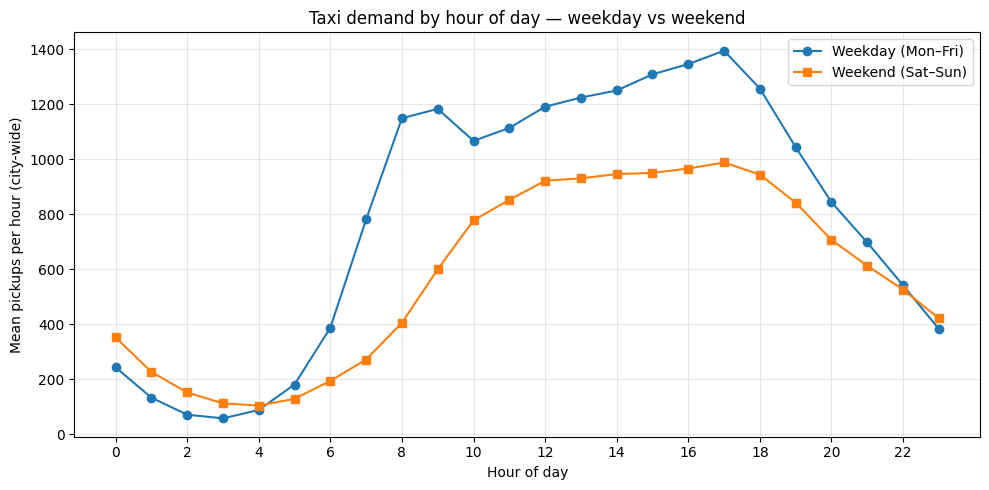

In [28]:
wd = city_hourly_mean(WEEKDAYS)
we = city_hourly_mean(WEEKEND)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wd.index, wd.values, marker="o", label="Weekday (Mon–Fri)")
ax.plot(we.index, we.values, marker="s", label="Weekend (Sat–Sun)")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean pickups per hour (city-wide)")
ax.set_title("Taxi demand by hour of day — weekday vs weekend")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


**2.1b Demand by day of week**

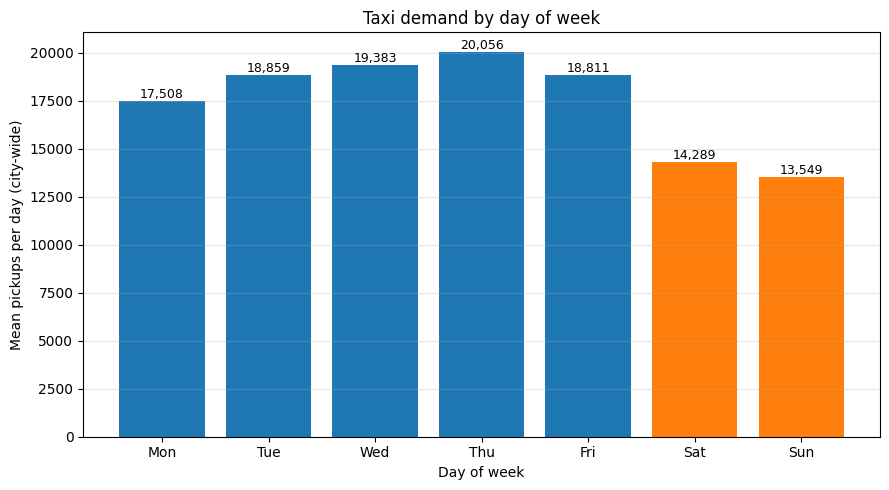

In [29]:
# Mean pickups per day, by day of week
daily = (agg_city_dow_hour.groupby("day_of_week")["n_trips"].sum())
daily_mean = pd.Series(
    {d: daily.get(d, 0) / N_DATES[d] for d in range(7)}
).reindex(range(7))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(7), daily_mean.values,
              color=["tab:blue"]*5 + ["tab:orange"]*2)  # weekend highlighted
ax.set_xticks(range(7)); ax.set_xticklabels(DOW_NAMES)
ax.set_xlabel("Day of week"); ax.set_ylabel("Mean pickups per day (city-wide)")
ax.set_title("Taxi demand by day of week")
ax.grid(True, axis="y", alpha=0.3)
# annotate values
for b, v in zip(bars, daily_mean.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

**2.1c Weekday × hour heatmap**


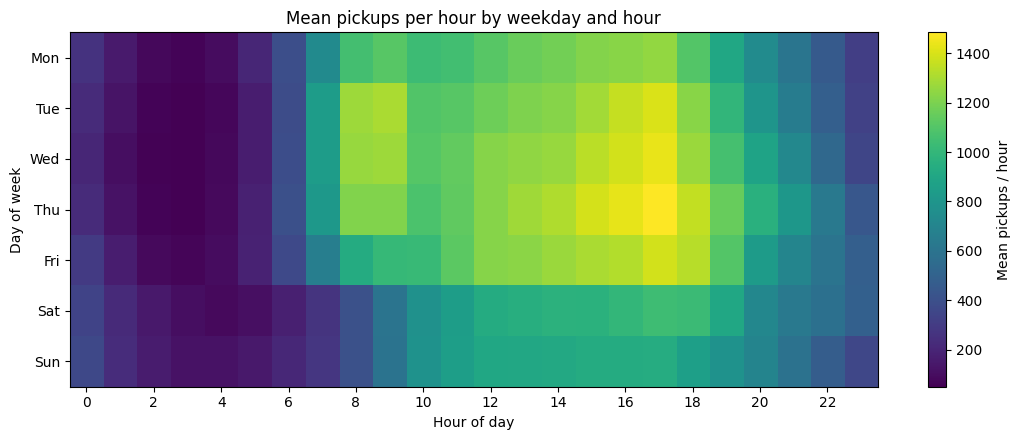

In [30]:
mat = np.full((7, 24), np.nan)
for _, r in agg_city_dow_hour.iterrows():
    d, h = int(r["day_of_week"]), int(r["hour"])
    mat[d, h] = r["n_trips"] / N_DATES[d]

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(mat, aspect="auto", cmap="viridis")
ax.set_yticks(range(7)); ax.set_yticklabels(DOW_NAMES)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel("Hour of day"); ax.set_ylabel("Day of week")
ax.set_title("Mean pickups per hour by weekday and hour")
fig.colorbar(im, ax=ax, label="Mean pickups / hour")
plt.tight_layout(); plt.show()


**2.1d Monthly demand profile**


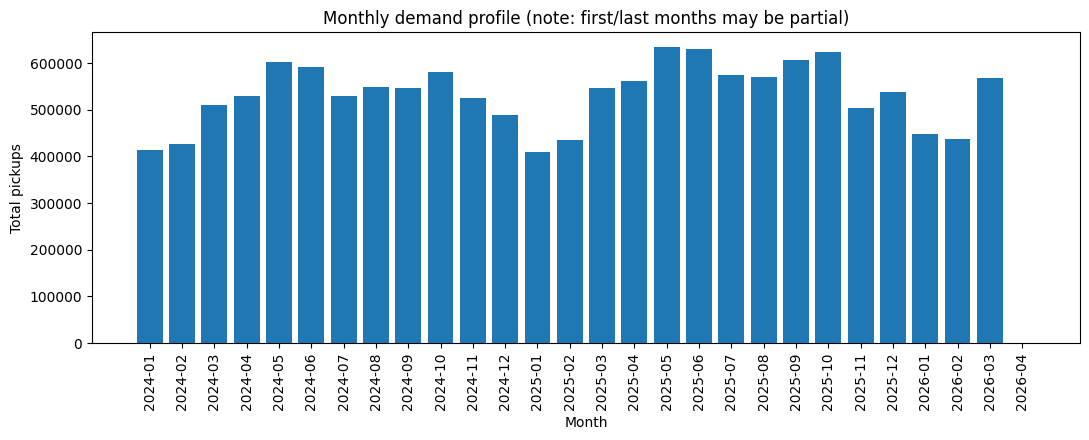

In [31]:
# Monthly demand profile over the full sample
m = agg_city_month.sort_values("month_start")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(m["month_start"].dt.strftime("%Y-%m"), m["n_trips"], color="tab:blue")
ax.set_xlabel("Month"); ax.set_ylabel("Total pickups")
ax.set_title("Monthly demand profile (note: first/last months may be partial)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()


Dropped partial month: 2026-04


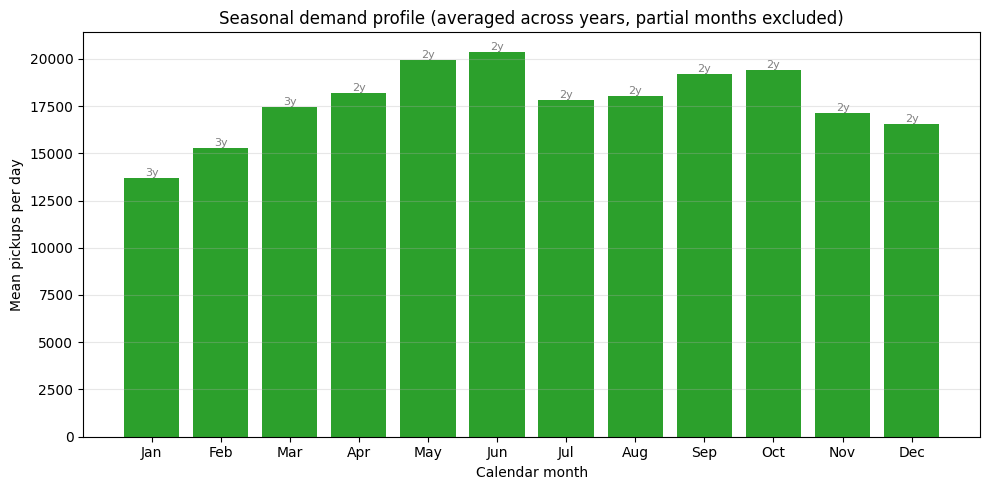

In [32]:
# Seasonal view: mean pickups per day, by calendar month (averaged across years)
# Drop the final partial month (April 2026 contains only the first few days)
m = agg_city_month.copy()
last_month = m["month_start"].max()
m = m[m["month_start"] != last_month]
print(f"Dropped partial month: {last_month.strftime('%Y-%m')}")

m["cal_month"] = m["month_start"].dt.month
m["year"]      = m["month_start"].dt.year
m["days_in_month"] = m["month_start"].dt.days_in_month

m["daily_mean"] = m["n_trips"] / m["days_in_month"]
seasonal = m.groupby("cal_month")["daily_mean"].mean().reindex(range(1, 13))
n_years  = m.groupby("cal_month")["year"].nunique().reindex(range(1, 13))

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(12), seasonal.values, color="tab:green")
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS)
ax.set_xlabel("Calendar month"); ax.set_ylabel("Mean pickups per day")
ax.set_title("Seasonal demand profile (averaged across years, partial months excluded)")
ax.grid(True, axis="y", alpha=0.3)
for b, n in zip(bars, n_years.values):
    if not np.isnan(b.get_height()):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(n)}y",
                ha="center", va="bottom", fontsize=8, color="grey")
plt.tight_layout(); plt.show()

**2.1e Trip-characteristic time courses by hour (weekday vs weekend)**

Distance, duration, fare and idle time per pickup hour. `utilization_rate` was dropped (never
defined in Task 1).


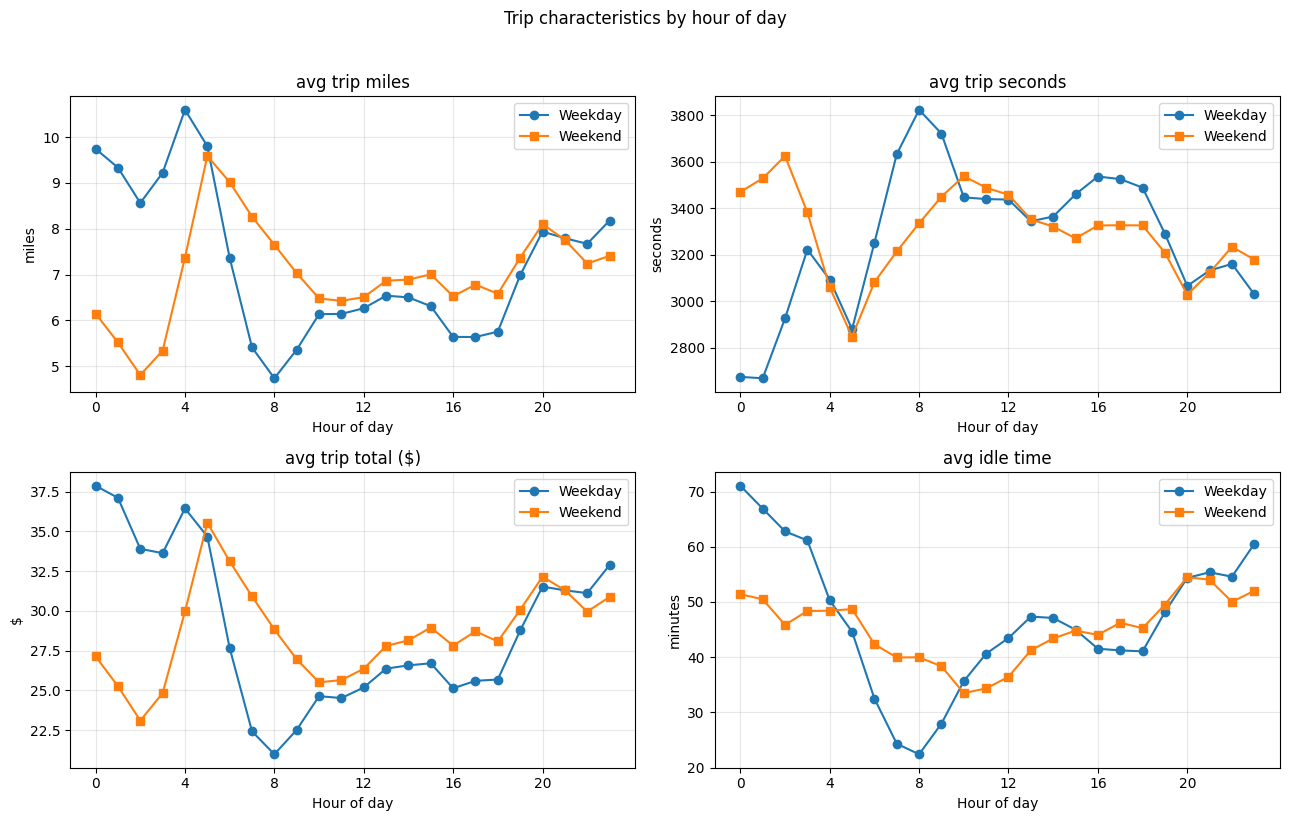

In [33]:
specs = [
    ("avg trip miles",     lambda d: city_charac_hourly("mean_trip_miles", d), "miles"),
    ("avg trip seconds",   lambda d: city_charac_hourly("mean_trip_secs", d),  "seconds"),
    ("avg trip total ($)", lambda d: city_charac_hourly("mean_trip_total", d), "$"),
    ("avg idle time",      lambda d: idle_hourly(d) / 60.0,                    "minutes"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (title, fn, unit) in zip(axes.ravel(), specs):
    ax.plot(range(24), fn(WEEKDAYS).values, marker="o", label="Weekday")
    ax.plot(range(24), fn(WEEKEND).values,  marker="s", label="Weekend")
    ax.set_title(title); ax.set_xlabel("Hour of day"); ax.set_ylabel(unit)
    ax.set_xticks(range(0, 24, 4)); ax.grid(True, alpha=0.3); ax.legend()
fig.suptitle("Trip characteristics by hour of day", y=1.02)
plt.tight_layout(); plt.show()


**2.1f Resolution beat: 1-hour vs 4-hour temporal binning**

The same city-wide demand, viewed at hourly resolution and at 4-hour resolution. Coarser binning
smooths the curve and hides the sharp commuting peaks — the first concrete demonstration of how
temporal resolution changes the observed pattern (expanded systematically in 2.7).


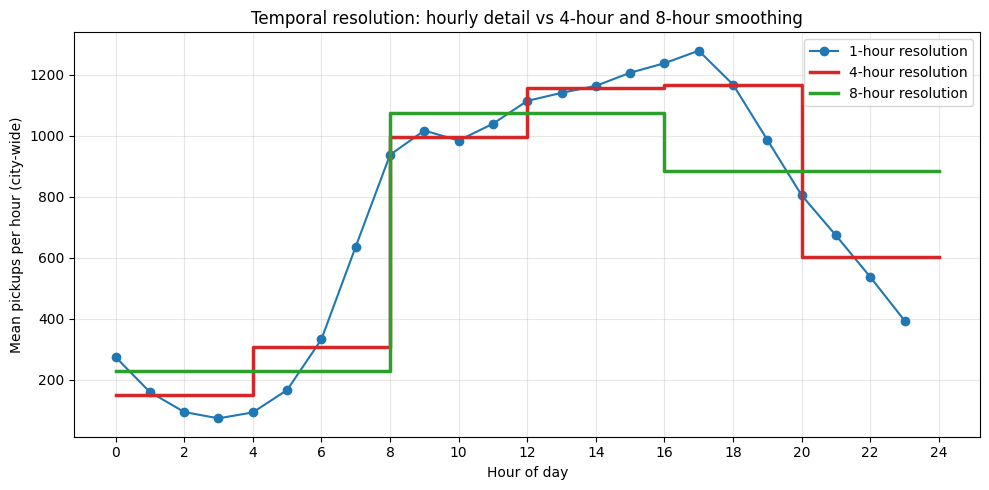

In [34]:
hourly_all = city_hourly_mean(WEEKDAYS + WEEKEND)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(24), hourly_all.values, marker="o", label="1-hour resolution")

for width, color, lbl in [(4, "tab:red", "4-hour resolution"),
                          (8, "tab:green", "8-hour resolution")]:
    binned = pd.Series(hourly_all.values).groupby(np.arange(24) // width).mean()
    x = np.arange(0, 24, width)
    # close the last bin: append x=24 and repeat the final y so the last segment is drawn
    x_closed = np.append(x, 24)
    y_closed = np.append(binned.values, binned.values[-1])
    ax.step(x_closed, y_closed, where="post", linewidth=2.5, color=color, label=lbl)

ax.set_xticks(range(0, 25, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean pickups per hour (city-wide)")
ax.set_title("Temporal resolution: hourly detail vs 4-hour and 8-hour smoothing")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### 2.2 Spatial Patterns and Hotspot Identification
Demand is aggregated over all hours and shown spatially through two complementary methods.

Grid-based:
- Choropleth of `demand_count` on Community Areas
- Choropleth of `demand_count` on H3 r? cells (default spatial unit)

Grid-free:
- Gaussian Mixture Model fitted on raw pickup coordinates (latitude, longitude), with the number of components selected via BIC
- Kernel Density Estimation on the same coordinates, plotted as contour map over Chicago

GMM is mandatory per the task description. KDE is added because the cluster centres from GMM do not visualise density gradients well; the contour map fills that gap. The grid-vs-grid-free comparison is the substantive point: if natural pickup clusters do not align with Community Area boundaries, the administrative units are the wrong service-zone proxy.


**2.2a — H3 choropleth (r6), with r8 for a resolution contrast**

Demand is highly concentrated (the Loop and the two airports dominate), so a log colour scale is
used. Side by side, r6 (coarser) and r8 (finer) show how grid size changes the apparent footprint
of demand.


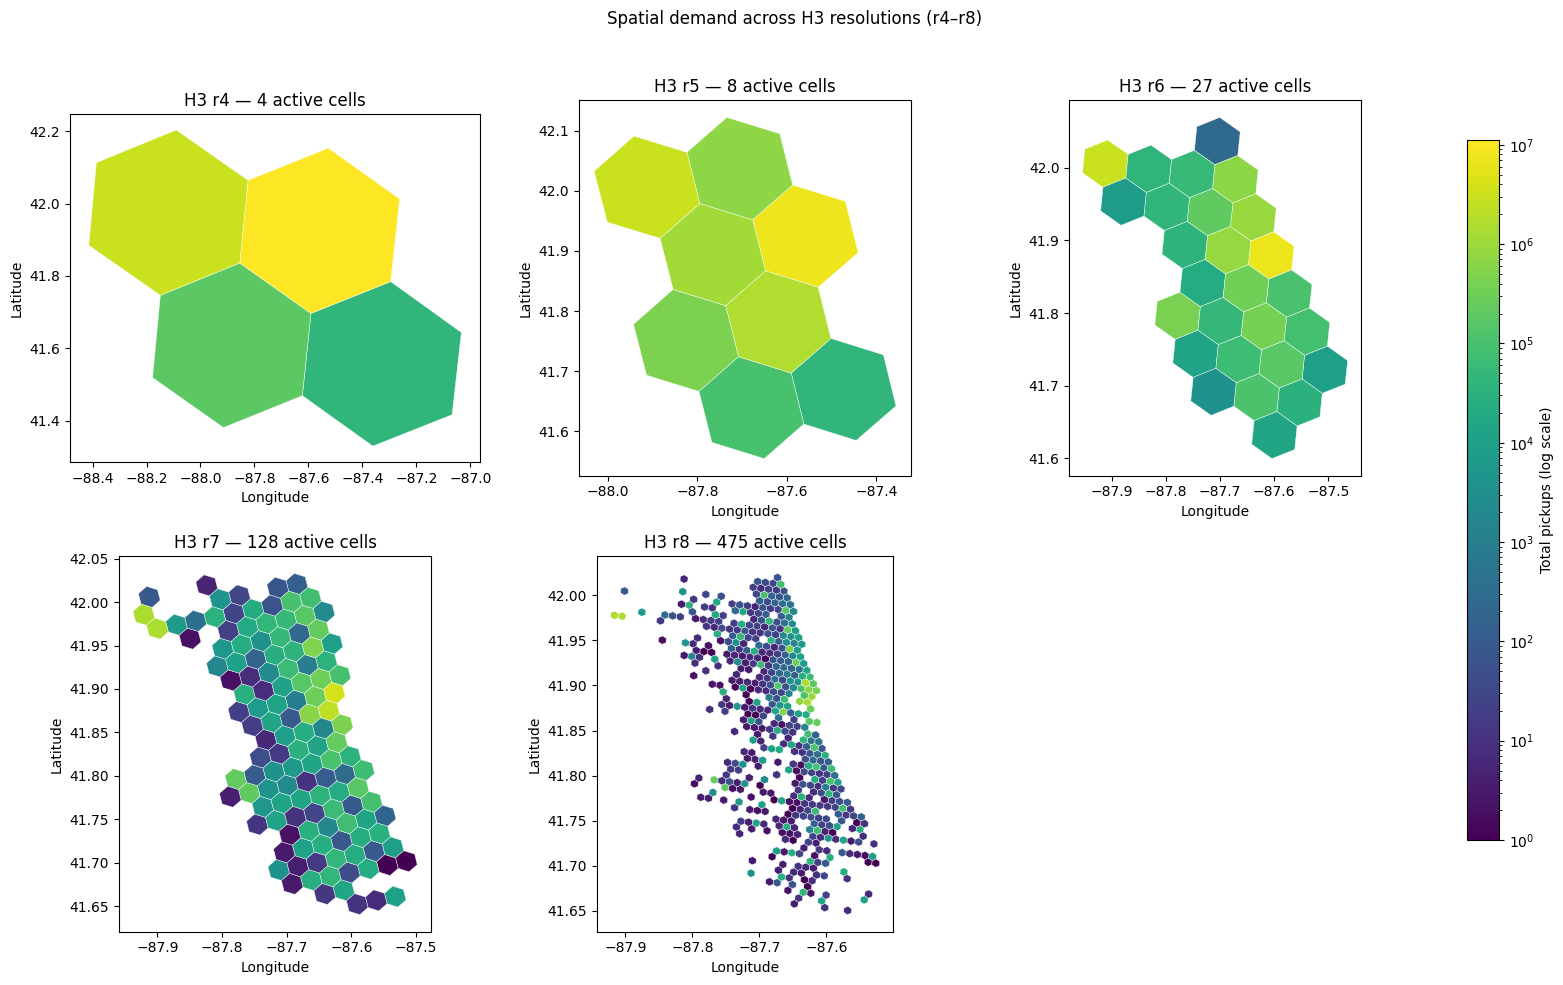

In [42]:
r4 = dict(zip(agg_h3r4_total["h3_r4"], agg_h3r4_total["n_trips"]))
r5 = dict(zip(agg_h3r5_total["h3_r5"], agg_h3r5_total["n_trips"]))
r6 = dict(zip(agg_h3r6_total["h3_r6"], agg_h3r6_total["n_trips"]))
r7 = dict(zip(agg_h3r7_total["h3_r7"], agg_h3r7_total["n_trips"]))
r8 = dict(zip(agg_h3r8_total["h3_r8"], agg_h3r8_total["n_trips"]))

panels = [("r4", r4), ("r5", r5), ("r6", r6), ("r7", r7), ("r8", r8)]
vmax = max(max(d.values()) for _, d in panels)
norm = LogNorm(vmin=1, vmax=vmax)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axflat = axes.ravel()
pc = None
for ax, (name, d) in zip(axflat, panels):
    pc = draw_hex_choropleth(ax, d, norm=norm,
                             title=f"H3 {name} — {len(d)} active cells")
    # each panel auto-scales to its own cells (no shared limits)

axflat[len(panels)].set_visible(False)   # hide unused 6th slot

fig.suptitle("Spatial demand across H3 resolutions (r4–r8)", y=0.98)
# leave room on the right, then put the colorbar in its own axis there
fig.tight_layout(rect=[0, 0, 0.90, 0.96])
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])   # [left, bottom, width, height]
fig.colorbar(pc, cax=cax, label="Total pickups (log scale)")
plt.show()

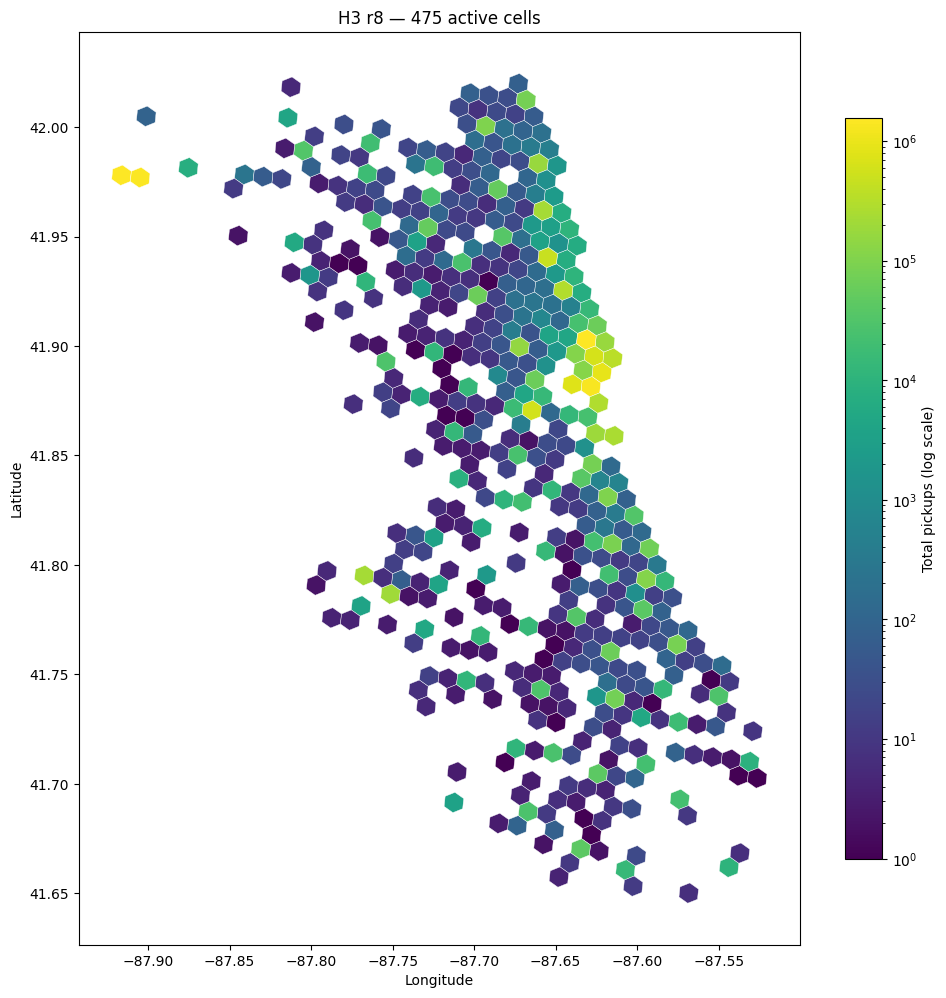

In [44]:
# Focus on r8 only
r8 = dict(zip(agg_h3r8_total["h3_r8"], agg_h3r8_total["n_trips"]))
norm = LogNorm(vmin=1, vmax=max(r8.values()))

fig, ax = plt.subplots(figsize=(10, 11))
pc = draw_hex_choropleth(ax, r8, norm=norm,
                         title=f"H3 r8 — {len(r8)} active cells")
fig.colorbar(pc, ax=ax, label="Total pickups (log scale)", shrink=0.7)
plt.tight_layout()
plt.show()

**2.2b — Community Area choropleth (administrative units)**

Requires the Chicago Community Area boundaries (a GeoJSON not contained in the trip data). If the
file and `geopandas` are available the true choropleth is drawn; otherwise a ranked bar chart of
the top areas is shown as a fallback, and the download URL is printed.


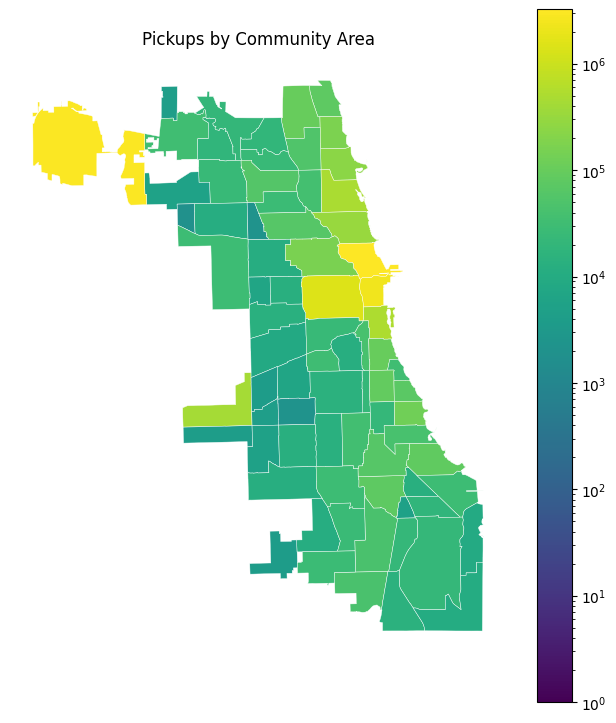

In [59]:
CA_GEOJSON = pathlib.Path("../data/chicago_community_areas.geojson")

# Download boundaries once if missing (so the cell is self-contained for teammates)
if not CA_GEOJSON.exists():
    import urllib.request
    CA_GEOJSON.parent.mkdir(parents=True, exist_ok=True)
    url = "https://data.cityofchicago.org/api/geospatial/igwz-8jzy?method=export&format=GeoJSON"
    urllib.request.urlretrieve(url, CA_GEOJSON)
    print("Downloaded:", CA_GEOJSON.stat().st_size, "bytes")

def _norm(s):
    # normalize CA keys to plain integer strings ("32.0" -> "32") for a clean join
    return s.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

ca = agg_ca_total.copy()
ca["pickup_community_area"] = _norm(ca["pickup_community_area"])

drawn = False
try:
    import geopandas as gpd
    if CA_GEOJSON.exists():
        gdf = gpd.read_file(CA_GEOJSON)
        # CA number field (this file: 'area_num_1' / 'area_numbe')
        key = next((c for c in ["area_num_1", "area_numbe", "community", "area_number"]
                    if c in gdf.columns), None)
        gdf["_key"] = _norm(gdf[key])
        gdf = gdf.merge(ca, left_on="_key", right_on="pickup_community_area", how="left")
        fig, ax = plt.subplots(figsize=(8, 9))
        gdf.plot(column="n_trips", cmap="viridis", legend=True, ax=ax,
                 norm=LogNorm(vmin=1, vmax=ca["n_trips"].max()),
                 missing_kwds={"color": "lightgrey"}, edgecolor="white", linewidth=0.3)
        ax.set_title("Pickups by Community Area"); ax.set_axis_off()
        plt.show(); drawn = True
    else:
        print(f"GeoJSON not found at {CA_GEOJSON}")
except ModuleNotFoundError:
    print("geopandas not installed — run: uv add geopandas")

if not drawn:
    top = ca.sort_values("n_trips", ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top["pickup_community_area"][::-1], top["n_trips"][::-1], color="tab:blue")
    ax.set_xlabel("Total pickups"); ax.set_ylabel("Community Area")
    ax.set_title("Top 20 Community Areas by pickups (fallback)")
    plt.tight_layout(); plt.show()

**2.2c — Gaussian Mixture Model on raw pickup coordinates (BIC-selected)**

GMM is mandatory per the task. It is fitted on the raw `(lat, lng)` points. The full 14M points
are infeasible to fit directly, so the model is fitted on a random sample — standard for density
modelling and statistically valid (the full coordinate set is preserved in `slim_trips`). The
number of components is chosen by minimum BIC.


In [68]:
from sklearn.mixture import GaussianMixture

coords = pd.read_parquet(PROCESSED / "slim_trips.parquet",
                         columns=["pickup_centroid_latitude", "pickup_centroid_longitude"]).dropna()
coords = coords.astype("float64") 
print(f"Total coordinate points available: {len(coords):,}")

Total coordinate points available: 14,382,862


Total coordinate points available: 14,382,862
Fitting GMM on a sample of 500,000 points
BIC-optimal components: 10


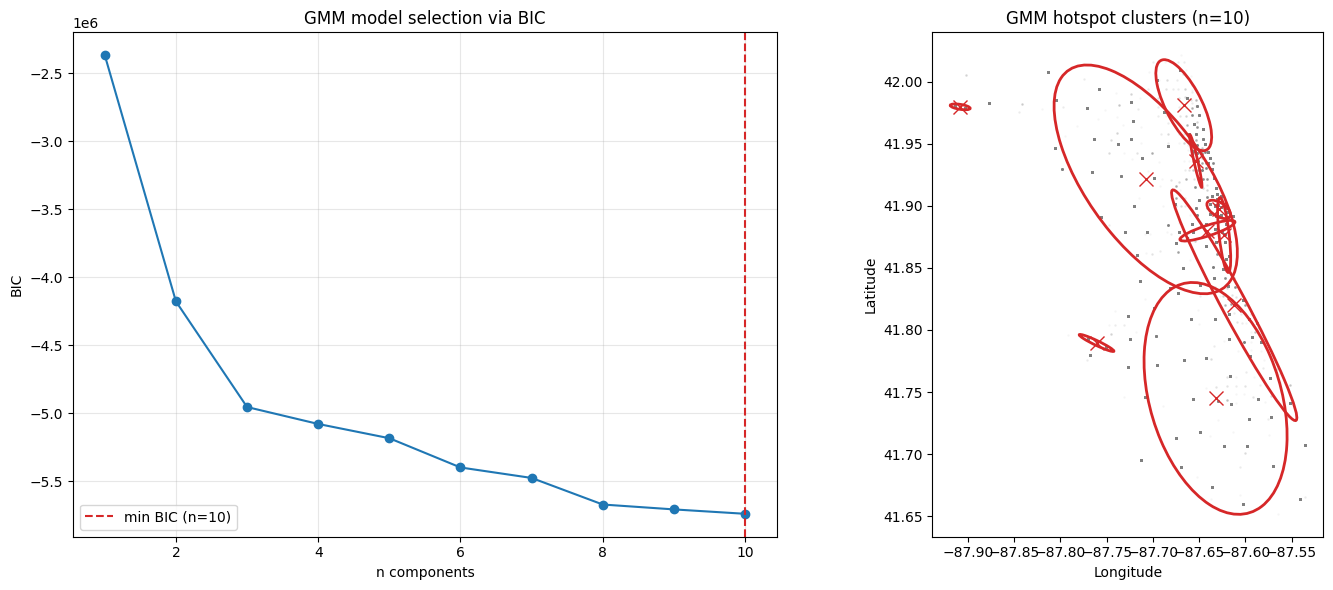

In [ ]:
rng = np.random.default_rng(42)
SAMPLE_N = min(500_000, len(coords))
idx = rng.choice(len(coords), size=SAMPLE_N, replace=False)
X = coords.to_numpy()[idx]          # columns: [lat, lng]
print(f"Fitting GMM on a sample of {SAMPLE_N:,} points")

ns = range(1, 11)
bics = []
for n in ns:
    g = GaussianMixture(n_components=n, covariance_type="full", random_state=0, n_init=1)
    g.fit(X)
    bics.append(g.bic(X))
best_n = list(ns)[int(np.argmin(bics))]
print(f"BIC-optimal components: {best_n}")

gmm = GaussianMixture(n_components=best_n, covariance_type="full", random_state=0).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(list(ns), bics, marker="o")
axes[0].axvline(best_n, color="tab:red", ls="--", label=f"min BIC (n={best_n})")
axes[0].set_xlabel("n components"); axes[0].set_ylabel("BIC")
axes[0].set_title("GMM model selection via BIC"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X[:, 1], X[:, 0], s=1, alpha=0.04, color="grey")  # lng, lat
from matplotlib.patches import Ellipse
for k in range(best_n):
    mean = gmm.means_[k]                 # [lat, lng]
    cov = gmm.covariances_[k][np.ix_([1, 0], [1, 0])]   # reorder to [lng, lat]
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * np.sqrt(vals) * 2        # ~2 std
    ax.add_patch(Ellipse((mean[1], mean[0]), w, h, angle=angle,
                         fill=False, edgecolor="tab:red", linewidth=2))
    ax.plot(mean[1], mean[0], "x", color="tab:red", markersize=10)
ax.set_aspect(1 / np.cos(np.radians(41.88)))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"GMM hotspot clusters (n={best_n})")
plt.tight_layout(); plt.show()


Total coordinate points available: 14,382,862
Fitting GMM on a sample of 500,000 points
BIC-optimal components: 17


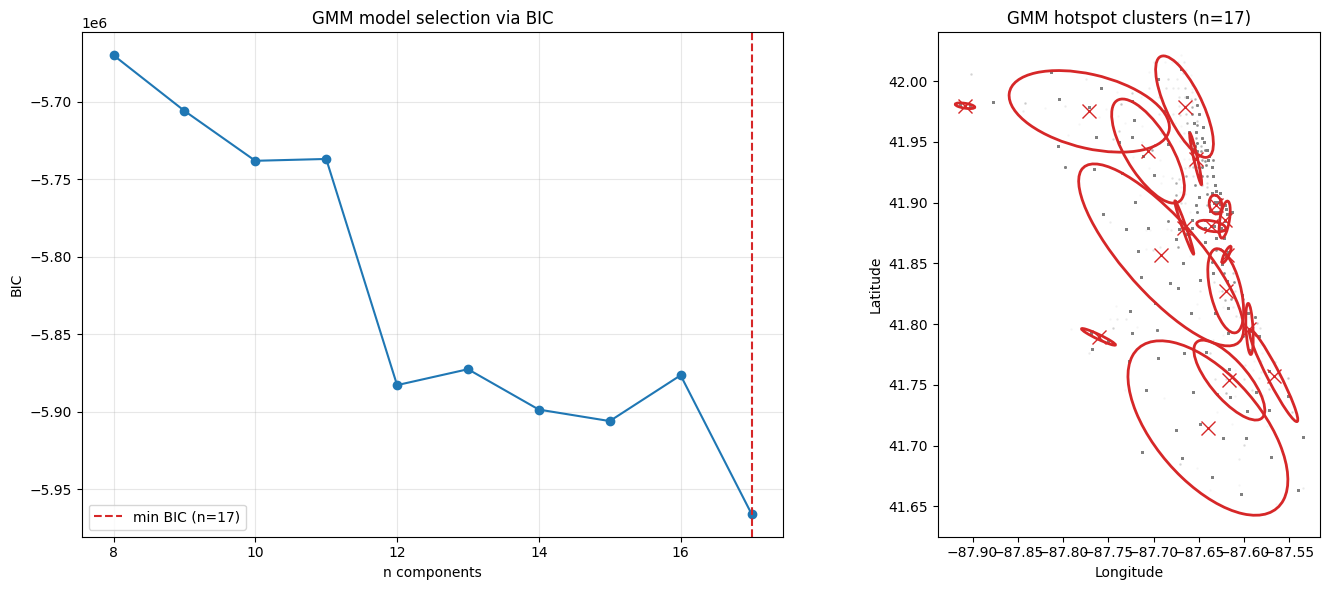

In [67]:
from sklearn.mixture import GaussianMixture

coords = pd.read_parquet(PROCESSED / "slim_trips.parquet",
                         columns=["pickup_centroid_latitude", "pickup_centroid_longitude"]).dropna()
coords = coords.astype("float64") 
print(f"Total coordinate points available: {len(coords):,}")

rng = np.random.default_rng(42)
SAMPLE_N = min(500_000, len(coords))
idx = rng.choice(len(coords), size=SAMPLE_N, replace=False)
X = coords.to_numpy()[idx]          # columns: [lat, lng]
print(f"Fitting GMM on a sample of {SAMPLE_N:,} points")

ns = range(8, 18)
bics = []
for n in ns:
    g = GaussianMixture(n_components=n, covariance_type="full", random_state=0, n_init=1)
    g.fit(X)
    bics.append(g.bic(X))
best_n = list(ns)[int(np.argmin(bics))]
print(f"BIC-optimal components: {best_n}")

gmm = GaussianMixture(n_components=best_n, covariance_type="full", random_state=0).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(list(ns), bics, marker="o")
axes[0].axvline(best_n, color="tab:red", ls="--", label=f"min BIC (n={best_n})")
axes[0].set_xlabel("n components"); axes[0].set_ylabel("BIC")
axes[0].set_title("GMM model selection via BIC"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X[:, 1], X[:, 0], s=1, alpha=0.04, color="grey")  # lng, lat
from matplotlib.patches import Ellipse
for k in range(best_n):
    mean = gmm.means_[k]                 # [lat, lng]
    cov = gmm.covariances_[k][np.ix_([1, 0], [1, 0])]   # reorder to [lng, lat]
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * np.sqrt(vals) * 2        # ~2 std
    ax.add_patch(Ellipse((mean[1], mean[0]), w, h, angle=angle,
                         fill=False, edgecolor="tab:red", linewidth=2))
    ax.plot(mean[1], mean[0], "x", color="tab:red", markersize=10)
ax.set_aspect(1 / np.cos(np.radians(41.88)))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"GMM hotspot clusters (n={best_n})")
plt.tight_layout(); plt.show()


**2.2d — Kernel Density Estimation contour**

KDE visualises the continuous density gradient that GMM's discrete clusters cannot. Evaluated on a
grid over Chicago and shown as filled contours over a faint scatter of the sample.


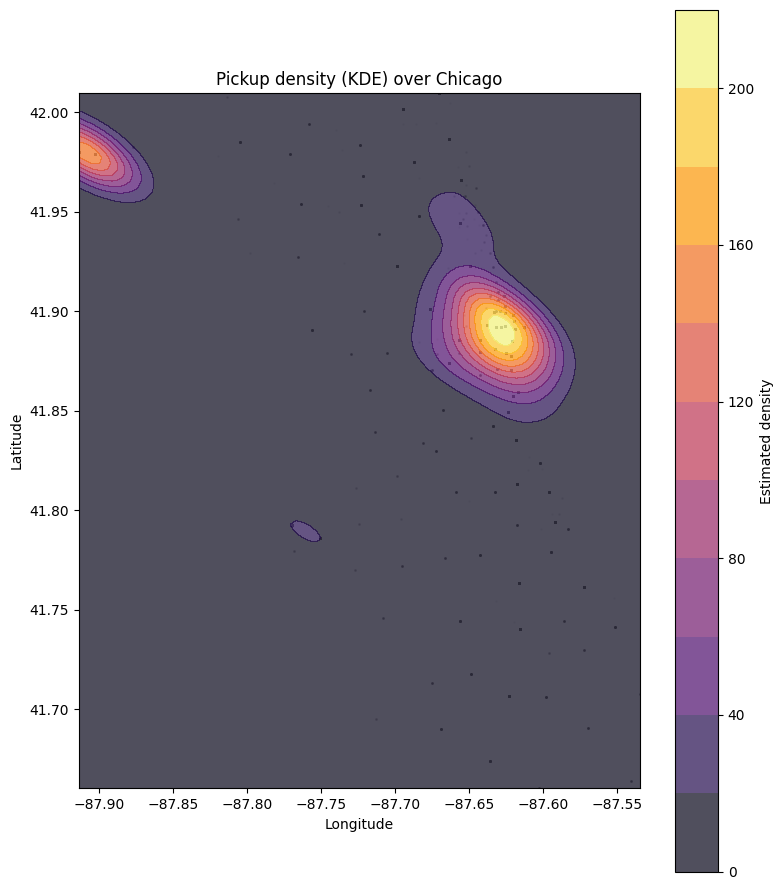

In [69]:
from scipy.stats import gaussian_kde

KDE_N = min(20_000, len(X))           # KDE is O(n*grid); a smaller sample is plenty for density
sub = X[rng.choice(len(X), size=KDE_N, replace=False)]
lat_s, lng_s = sub[:, 0], sub[:, 1]

kde = gaussian_kde(np.vstack([lng_s, lat_s]))
lng_min, lng_max = lng_s.min(), lng_s.max()
lat_min, lat_max = lat_s.min(), lat_s.max()
gx, gy = np.mgrid[lng_min:lng_max:120j, lat_min:lat_max:120j]
dens = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(8, 9))
ax.scatter(lng_s, lat_s, s=1, alpha=0.05, color="grey")
cf = ax.contourf(gx, gy, dens, levels=12, cmap="inferno", alpha=0.7)
ax.set_aspect(1 / np.cos(np.radians(41.88)))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Pickup density (KDE) over Chicago")
fig.colorbar(cf, ax=ax, label="Estimated density")
plt.tight_layout(); plt.show()


### 2.3 Spatio-Temporal Interplay
`demand_count` is shown jointly over (spatial unit × time). Three artefacts:

- Heatmap matrix: rows = top-N H3 r? cells (or Community Areas), columns = hour of day, colour = mean `demand_count`
- Small multiples: four to six maps of Chicago at representative time slices (e.g. weekday 1am, 7am, 1pm, 7pm; vs. Saturday?), choropleth on the same spatial unit as 2.2
- Line plot: hourly demand profile for the top five hexagons over a typical day

The three artefacts exist because no single plot captures both dimensions well. The matrix is dense and exact but loses geography; the small multiples retain geography but lose continuity; the line plot makes the dynamics of individual hotspots readable.


**2.3a — Heatmap matrix: top-N H3 r6 cells × hour of day**

Rows are the busiest r6 cells, columns are hour of day, colour is mean pickups per hour. A log
colour scale keeps the airport/Loop cells from flattening everything else.


In [72]:
print(agg_h3r6_dow_hour.dtypes)

h3_r6          category
day_of_week        int8
hour               int8
n_trips           Int64
dtype: object


Top H3 r6 cells by demand:
  # 1  862664c1fffffff  (41.8794, -87.6055)   46.8%
  # 2  862759347ffffff  (42.0059, -87.9126)   20.7%
  # 3  862664c17ffffff  (41.9319, -87.6387)    6.6%
  # 4  862664cafffffff  (41.8866, -87.6855)    6.1%
  # 5  862664d8fffffff  (41.9844, -87.6720)    4.5%
  # 6  862664527ffffff  (41.7962, -87.7788)    3.0%
  # 7  862664cc7ffffff  (41.7817, -87.6191)    2.6%
  # 8  862664cf7ffffff  (41.8342, -87.6523)    2.3%
  # 9  862664ca7ffffff  (41.9391, -87.7188)    1.5%
  #10  862664ccfffffff  (41.7293, -87.5860)    1.1%
  #11  862664567ffffff  (41.6842, -87.6327)    0.8%
  #12  862664ce7ffffff  (41.8269, -87.5723)    0.7%


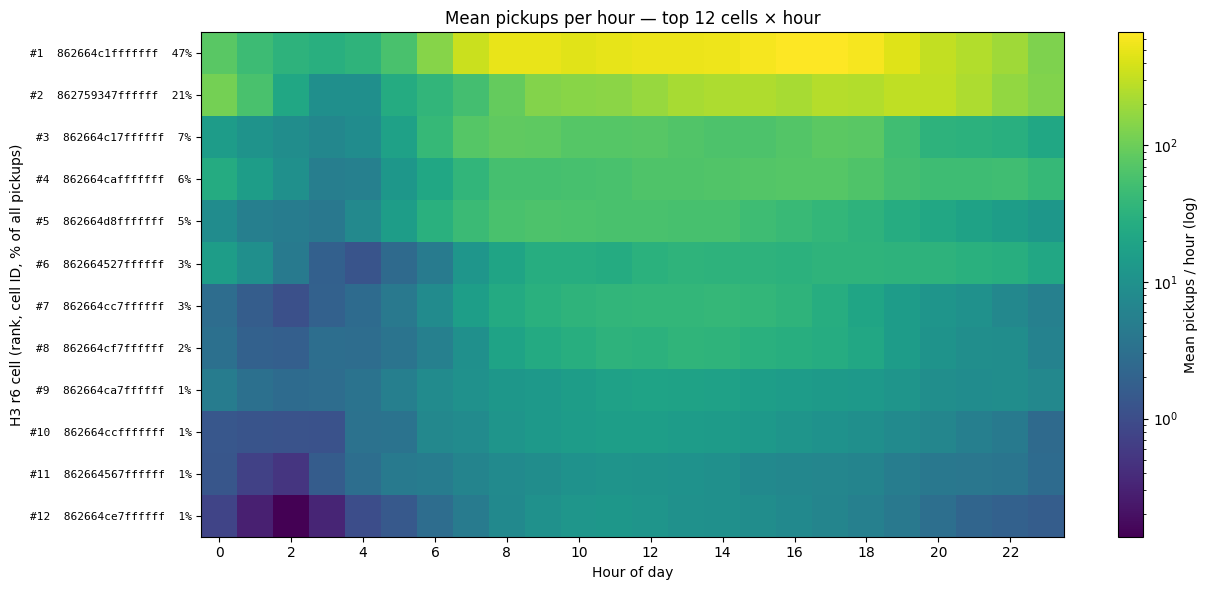

In [78]:
import h3

N_TOP = 12
cell_tot = agg_h3r6_dow_hour.groupby("h3_r6")["n_trips"].sum().sort_values(ascending=False)
top_cells = cell_tot.head(N_TOP).index.tolist()
total_all = cell_tot.sum()

# Label cells by rank, H3 cell ID, centroid coordinates, and share of all pickups
# (H3 cells are a uniform geometric grid — they do not correspond to city districts)
print("Top H3 r6 cells by demand:")
labels = []
for rank, c in enumerate(top_cells, 1):
    lat, lng = h3.cell_to_latlng(c)
    share = cell_tot[c] / total_all * 100
    print(f"  #{rank:>2}  {c}  ({lat:.4f}, {lng:.4f})  {share:5.1f}%")
    labels.append(f"#{rank}  {c}  {share:.0f}%")

# Mean pickups per hour-of-day
hour_of_day = (agg_h3r6_dow_hour.groupby(["h3_r6", "hour"])["n_trips"].sum()
               / TOTAL_DATES).rename("mean_demand").reset_index()
pivot = (hour_of_day[hour_of_day["h3_r6"].isin(top_cells)]
         .pivot(index="h3_r6", columns="hour", values="mean_demand")
         .reindex(index=top_cells, columns=range(24)).fillna(0)
         .astype("float64"))

# Heatmap
fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis",
               norm=LogNorm(vmin=max(pivot.values[pivot.values > 0].min(), 0.1),
                            vmax=pivot.values.max()))
ax.set_yticks(range(N_TOP)); ax.set_yticklabels(labels, fontsize=8, fontfamily="monospace")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("H3 r6 cell (rank, cell ID, % of all pickups)")
ax.set_title(f"Mean pickups per hour — top {N_TOP} cells × hour")
fig.colorbar(im, ax=ax, label="Mean pickups / hour (log)")
plt.tight_layout(); plt.show()

**2.3b — Small multiples: demand maps at representative time slices**

The spatial footprint of demand at four hours of a typical weekday, plus the same hours on
Saturday. All panels share one colour scale so they are directly comparable.


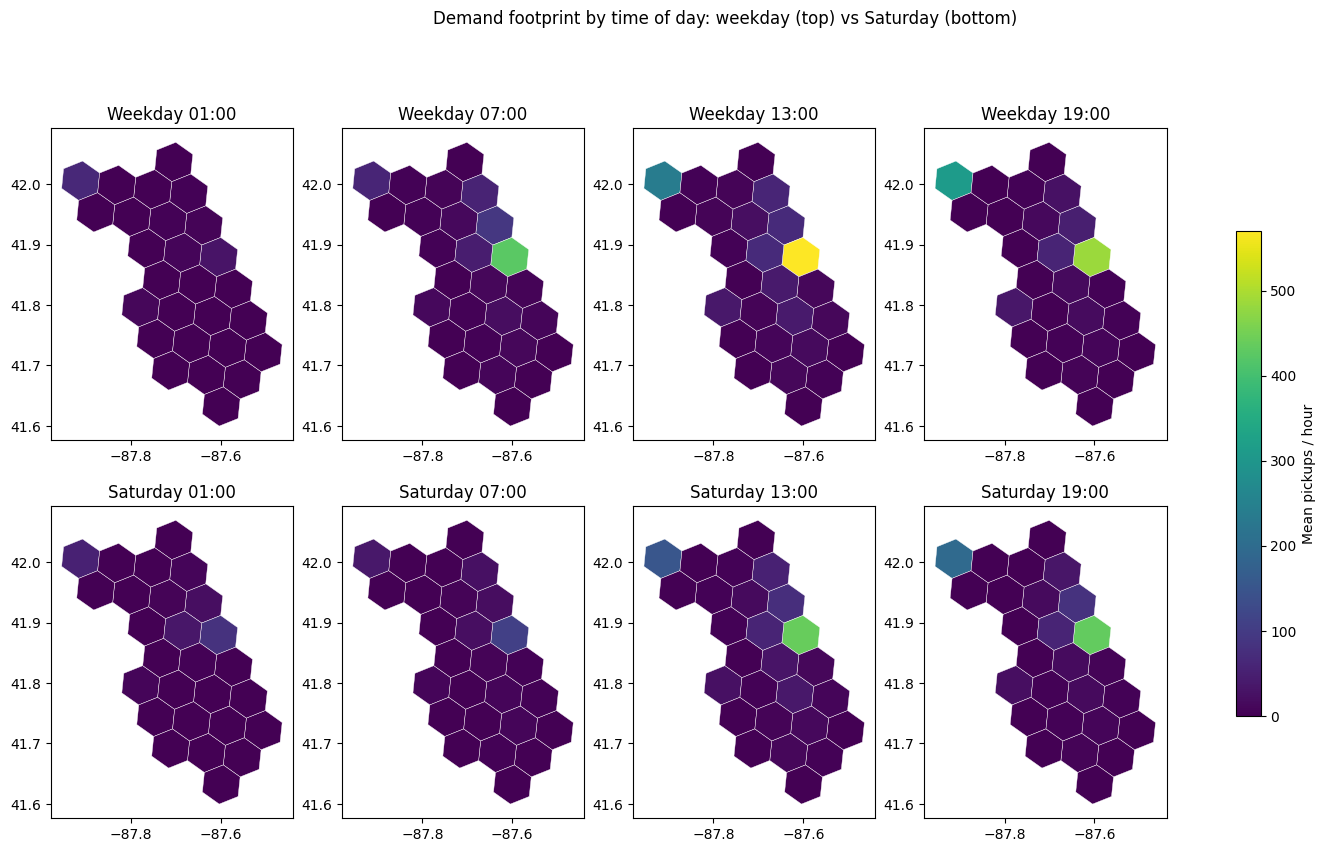

In [79]:
def cell_demand_at(hour, dows):
    sub = agg_h3r6_dow_hour[(agg_h3r6_dow_hour["hour"] == hour) &
                            (agg_h3r6_dow_hour["day_of_week"].isin(dows))]
    n_days = sum(N_DATES[d] for d in dows)
    s = sub.groupby("h3_r6")["n_trips"].sum() / n_days
    return s.to_dict()

slices = [(1, "01:00"), (7, "07:00"), (13, "13:00"), (19, "19:00")]
all_cells = agg_h3r6_total["h3_r6"].tolist()

# global vmax across all panels for a shared scale
panel_data = []
for h, lbl in slices:
    panel_data.append((f"Weekday {lbl}", cell_demand_at(h, WEEKDAYS)))
for h, lbl in slices:
    panel_data.append((f"Saturday {lbl}", cell_demand_at(h, [5])))
gmax = max((max(d.values()) if d else 0) for _, d in panel_data)
norm = Normalize(vmin=0, vmax=gmax)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, d) in zip(axes.ravel(), panel_data):
    full = {c: d.get(c, 0.0) for c in all_cells}   # show 0 for inactive cells
    pc = draw_hex_choropleth(ax, full, norm=norm, title=title, edgecolor="white")
    ax.set_xlabel(""); ax.set_ylabel("")
fig.colorbar(pc, ax=axes, label="Mean pickups / hour", shrink=0.7)
fig.suptitle("Demand footprint by time of day: weekday (top) vs Saturday (bottom)", y=1.01)
plt.show()


**2.3c — Hourly demand profile for the top five hexagons**

How the busiest cells rise and fall over a typical day. The airport cells peak differently from
the downtown cells — the operational reason small multiples and the matrix are complementary.


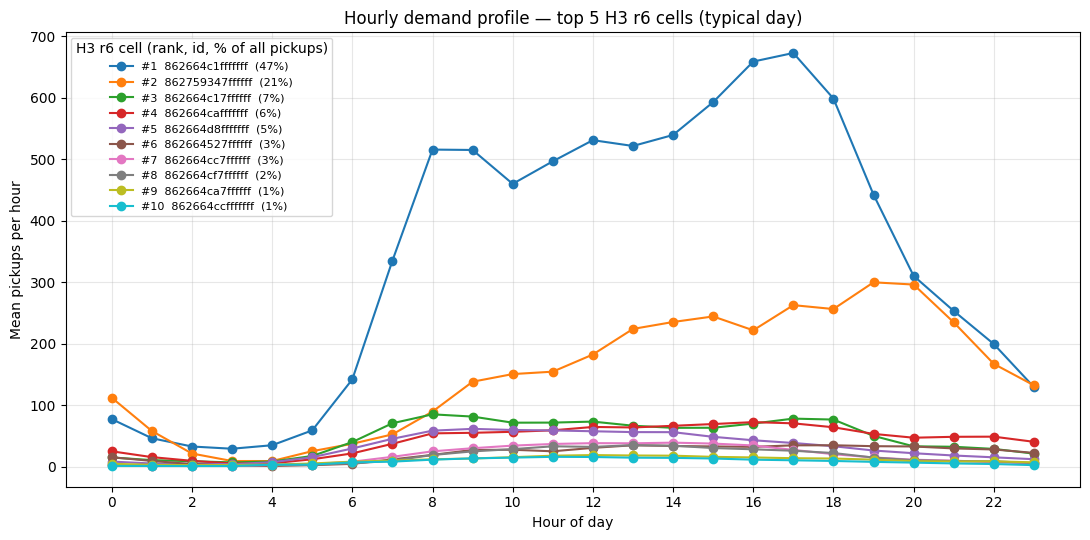

In [83]:
top5 = cell_tot.head(10).index.tolist()
total_all = cell_tot.sum()

fig, ax = plt.subplots(figsize=(11, 5.5))
for rank, c in enumerate(top5, 1):
    series = (hour_of_day[hour_of_day["h3_r6"] == c]
              .set_index("hour")["mean_demand"].reindex(range(24), fill_value=0))
    share = cell_tot[c] / total_all * 100
    ax.plot(series.index, series.values, marker="o",
            label=f"#{rank}  {c}  ({share:.0f}%)")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean pickups per hour")
ax.set_title("Hourly demand profile — top 5 H3 r6 cells (typical day)")
ax.grid(True, alpha=0.3)
ax.legend(title="H3 r6 cell (rank, id, % of all pickups)", fontsize=8)
plt.tight_layout(); plt.show()

---
### Notes and limitations carried into later sections
- **Concentration:** a handful of r6 cells (Loop + airports) dominate all spatial views; log scales
  and top-N selection are used so the long tail stays visible.
- **Sampling:** GMM/KDE are *fitted* on coordinate samples for tractability; the full coordinate set
  is preserved upstream. Counts and choropleths use the complete data.
- **Community Area choropleth** needs an external boundary file (see 2.2b) — the only required
  output that depends on data outside the trip table.
- **Resolution** is previewed in 2.1e (1h vs 4h) and 2.2a (r6 vs r8); the systematic treatment is 2.7.


### 2.4 Origin-Destination Flows
Pickup → dropoff pairs are aggregated at Community Area level (H3 r? produces too many low-volume pairs for a readable OD analysis). Required outputs:

- Top 20–50 OD pairs as a sorted table with trip count, mean trip distance and mean trip total
- Chord or Sankey diagram of the major flows (I don't even know what that is, but AI says it should be good)
- Asymmetry score per OD pair: `(forward − backward) / (forward + backward)`, used to flag corridors with structural repositioning need

Anchoring on pickups alone misses where vehicles end up after a trip, which is the relevant question for repositioning.

### 2.5 External Drivers: Weather
The hourly weather data from Section 1.5 is merged onto the hourly demand aggregate by `timestamp_h`. Required outputs:

- `demand_count` vs. `temp_h`, binned and plotted with median and IQR per bin
- Same for `precip_h` and `snow_h`
- Comparison of rainy vs. dry days at the same hour of day, to control for the time-of-day confound (rain peaks in the afternoon, demand also peaks in the afternoon — a raw correlation would mostly capture this)
- in generel problem of analyzing temp e.g., because this correlates with time => so try to cancel time-influence and look at data always at 4pm e.g. with different temps. 

Snowfall is analysed only for the winter months; outside winter the signal is too sparse. Weather has only a temporal component, so all comparisons here are city-level.

### 2.6 Spatial Variation in Trip Characteristics
For each Community Area and each H3 r? cell, the following per-area statistics are computed and visualised as choropleths (maybe I am listing too many variables, please recheck):

- mean `trip_miles`, mean `trip_seconds`
- mean `trip_total`, `price_per_mile`, `price_per_minute`
- mean `avg_speed_mph` (operational congestion indicator)
- median `idle_time` per taxi (skewed distribution, so median is used)
- mean `utilization_rate` (active driving time over time on shift)
- mean repositioning distance (Haversine from dropoff to next pickup of the same taxi, averaged within area)
- mean detour factor (`trip_miles` over straight-line pickup–dropoff distance)
- number of distinct companies operating in the area
- share of digital payments (`payment_type` ∈ {Credit Card, Mobile})
- mean tip rate (`tips` / `fare`, conditioned on `fare > 0`)

2.2 counts pickups; 2.6 describes what those pickups produce. Two areas can show the same `demand_count` and produce completely different trip economics, which drives fleet sizing, charging cadence and revenue per pickup.

### 2.7 Resolution Sensitivity
**Spatial sensitivity** (1h aggregate, H3 r4 / r6 / r8 + Community Areas):
- Table per resolution: number of cells, share of (cell × hour) with `demand_count > 0`, median and 99th-percentile demand, Gini coefficient
- Overlay histogram of `demand_count` distributions across resolutions
- Same hour of the same day on a map at three resolutions side by side

Census Tracts are excluded — Section 1.3 documented a 55% missing share, which would dominate any sensitivity effect.

**Temporal sensitivity** (H3 r?, 1h / 4h / 1d): short table on zero-rate and coefficient of variation, plus one example heatmap (cell × time) at the three bin widths. Treated briefly because temporal aggregation is a smoothing operation — variance drops with bin width, but the daily cycle shape does not change.

**GMM vs. grid**: one map with raw pickup points, GMM cluster centres from 2.2 and the top-10 cells at H3 r6 and r8 outlined; short note on the share of pickups captured by each. The point is that GMM is grid-independent, while grid-based hotspots are distorted by cell size — coarse grids merge separate clusters, fine grids split single ones.

Closes with a recommended spatial resolution for the predictive modelling in Section 3, chosen by the trade-off between spatial detail and zero-inflation of the target.

### 2.8 Summary and Implications
The findings from 2.1–2.7 are mapped onto the three consulting questions from Section 1.1:

- Strategic: which areas show consistently high demand across hours and weeks
- Tactical: how demand varies by hour, weekday and weather, with implications for vehicle counts
- Operational: where idle times and repositioning distances are highest, and where the trip mix favours short, high-throughput pickups versus long airport-style trips